# Men's World Cup — home win vs not

This notebook does **one thing end-to-end**:

1. **Restrict to men's World Cups** in the processed table (odd `year` rows are women's editions).
2. **Leave-one-tournament-out (LOTO) cross-validation** over the six modern men's tournaments in the extract (2002–2022, 64 matches each): each edition is held out once; the model trains on the other five.
3. **SHAP** for global importance (mean |SHAP| averaged over LOTO test folds) and a **summary plot** for the 2022 holdout as a concrete example.

**Data:** `data/processed/class_a_match_level.parquet` at repo root (from notebook `01`).  
**Target:** `y_win` = 1 if home team wins, else 0 (draw or away win).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    import shap
except ImportError as e:
    raise ImportError(
        "Install SHAP in this environment, e.g. `pip install shap`, then restart the kernel."
    ) from e


def repo_root() -> Path:
    """Project root (folder that contains ``notebooks/``)."""
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "notebooks").is_dir() and (candidate / "README.md").is_file():
            return candidate
    if p.name == "eda_worldcup":
        return p.parent.parent
    if p.name == "notebooks":
        return p.parent
    return p


REPO_ROOT = repo_root()
DATA_PATH = REPO_ROOT / "data" / "processed" / "class_a_match_level.parquet"
if not DATA_PATH.is_file():
    DATA_PATH = REPO_ROOT / "data" / "processed" / "class_a_match_level.csv"

assert DATA_PATH.is_file(), f"Run notebook 01 first: {DATA_PATH}"

df = (
    pd.read_parquet(DATA_PATH)
    if DATA_PATH.suffix == ".parquet"
    else pd.read_csv(DATA_PATH)
)
print("Loaded:", df.shape)

Loaded: (1248, 104)


## 1) Men's editions only

The SQLite extract interleaves **women's** World Cups on **odd** calendar years (e.g. 2003, 2007, …). For men's-only modeling we keep the six tournaments that match the usual men's cadence in this database:

`2002, 2006, 2010, 2014, 2018, 2022` → **384** match rows (64 per edition).

In [2]:
MENS_WORLD_CUP_YEARS = [2002, 2006, 2010, 2014, 2018, 2022]

dm = df[df["year"].isin(MENS_WORLD_CUP_YEARS)].copy()
assert len(dm) == 384, f"Expected 384 men's rows, got {len(dm)}"

print("Rows per men's tournament year:")
display(dm.groupby("year").size().to_frame("n_matches"))

print("Home-win rate by year:")
display(dm.groupby("year")["y_win"].mean().round(3).to_frame("home_win_rate"))

Rows per men's tournament year:


,n_matches
year,
2002,64
2006,64
2010,64
2014,64
2018,64
2022,64


Home-win rate by year:


,home_win_rate
year,
2002,0.438
2006,0.531
2010,0.391
2014,0.484
2018,0.422
2022,0.500


## 2) Feature matrix

Numeric columns only; drop IDs, label, and string schedule fields (encode separately later if needed). `era` is dropped if present.

In [3]:
id_cols = ["match_id", "tournament_id", "home_team_id", "away_team_id"]
non_feature = set(id_cols + ["y_win", "stage_name", "group_name", "year"])
non_feature.add("era")

num_cols = [
    c
    for c in dm.columns
    if c not in non_feature and pd.api.types.is_numeric_dtype(dm[c])
]
num_cols = sorted(num_cols)
print(len(num_cols), "numeric features")

X_all = dm[num_cols]
y_all = dm["y_win"].astype(int)

96 numeric features


## 3) Leave-one-tournament-out (LOTO) cross-validation

For each men's `year` *Y*, train on all rows with `year != Y`, test on `year == Y`. Model: median imputation → standardization → **L2 logistic** (`class_weight="balanced"`).

Metrics: **ROC-AUC** and **accuracy** on the 64 held-out matches.

In [4]:
def make_pipe():
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=500, class_weight="balanced", random_state=42
                ),
            ),
        ]
    )


loto_rows = []
mean_abs_shap = np.zeros(len(num_cols), dtype=float)
shap_explanation_2022 = None
X_test_scaled_2022 = None

for holdout in MENS_WORLD_CUP_YEARS:
    tr = dm["year"] != holdout
    te = dm["year"] == holdout
    X_tr, y_tr = X_all.loc[tr], y_all.loc[tr]
    X_te, y_te = X_all.loc[te], y_all.loc[te]

    pipe = make_pipe()
    pipe.fit(X_tr, y_tr)
    proba = pipe.predict_proba(X_te)[:, 1]
    pred = pipe.predict(X_te)
    yt = np.asarray(y_te)

    loto_rows.append(
        {
            "holdout_year": holdout,
            "n_train": int(tr.sum()),
            "n_test": int(te.sum()),
            "roc_auc": float(roc_auc_score(yt, proba)),
            "accuracy": float(accuracy_score(yt, pred)),
        }
    )

    imputer = pipe.named_steps["imputer"]
    scaler = pipe.named_steps["scaler"]
    lr = pipe.named_steps["clf"]
    X_te_s = scaler.transform(imputer.transform(X_te))
    X_tr_s = scaler.transform(imputer.transform(X_tr))
    explainer = shap.LinearExplainer(lr, X_tr_s)
    exp = explainer(X_te_s)
    mean_abs_shap += np.abs(exp.values).mean(axis=0)

    if holdout == 2022:
        shap_explanation_2022 = exp
        X_test_scaled_2022 = X_te_s

loto_df = pd.DataFrame(loto_rows).sort_values("holdout_year")
display(loto_df.round(4))

print(
    "LOTO ROC-AUC: mean =",
    round(loto_df["roc_auc"].mean(), 4),
    "std =",
    round(loto_df["roc_auc"].std(), 4),
    "| min–max:",
    round(loto_df["roc_auc"].min(), 4),
    "–",
    round(loto_df["roc_auc"].max(), 4),
)
print(
    "LOTO accuracy: mean =",
    round(loto_df["accuracy"].mean(), 4),
    "std =",
    round(loto_df["accuracy"].std(), 4),
)

mean_abs_shap /= len(MENS_WORLD_CUP_YEARS)
imp_df = (
    pd.DataFrame({"feature": num_cols, "mean_abs_shap_loto_avg": mean_abs_shap})
    .sort_values("mean_abs_shap_loto_avg", ascending=False)
    .reset_index(drop=True)
)
print("Top 15 features by mean |SHAP| averaged over LOTO test sets:")
display(imp_df.head(15).round(5))

,holdout_year,n_train,n_test,roc_auc,accuracy
0,2002,320,64,0.5685,0.5781
1,2006,320,64,0.6461,0.5938
2,2010,320,64,0.7662,0.6875
3,2014,320,64,0.7038,0.6406
4,2018,320,64,0.6476,0.5938
5,2022,320,64,0.6318,0.6250


LOTO ROC-AUC: mean = 0.6607 std = 0.0674 | min–max: 0.5685 – 0.7662
LOTO accuracy: mean = 0.6198 std = 0.0403
Top 15 features by mean |SHAP| averaged over LOTO test sets:


,feature,mean_abs_shap_loto_avg
0,home_hist_et_matches,0.53163
1,home_squad_n_fw,0.50250
2,away_hist_wins,0.49515
3,home_hist_draws,0.47451
4,home_hist_ko_matches,0.45825
5,home_squad_share_any_prior_wc,0.44603
6,home_squad_prior_wc_mean,0.43636
7,away_hist_ko_matches,0.42214
8,away_hist_pso_wins,0.38354
9,feat_away_hist_win_rate_vs_home_conf,0.34911


## 4) SHAP plots

- **Bar chart:** ranking from **mean |SHAP|** averaged across all six LOTO test folds (same model class each time).
- **Summary (beeswarm):** SHAP values for the **2022-only** holdout fold—illustrates direction of effect for that tournament.

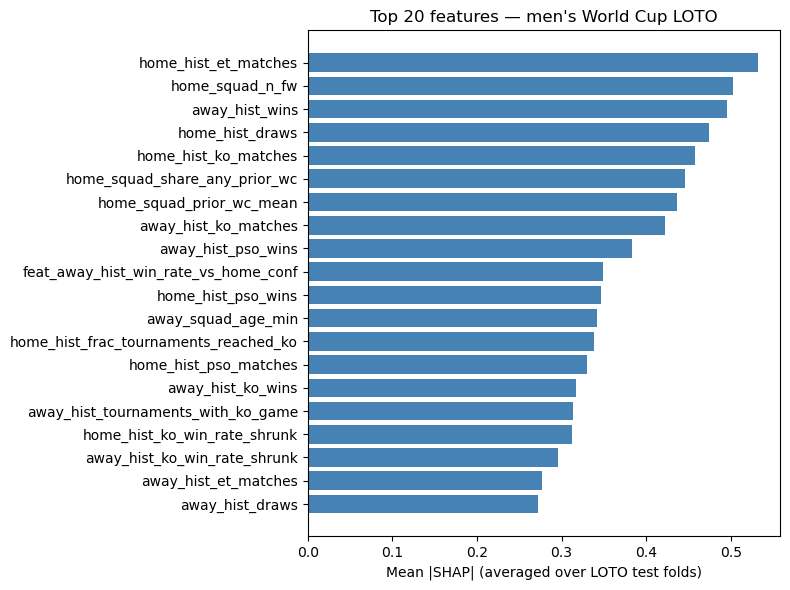

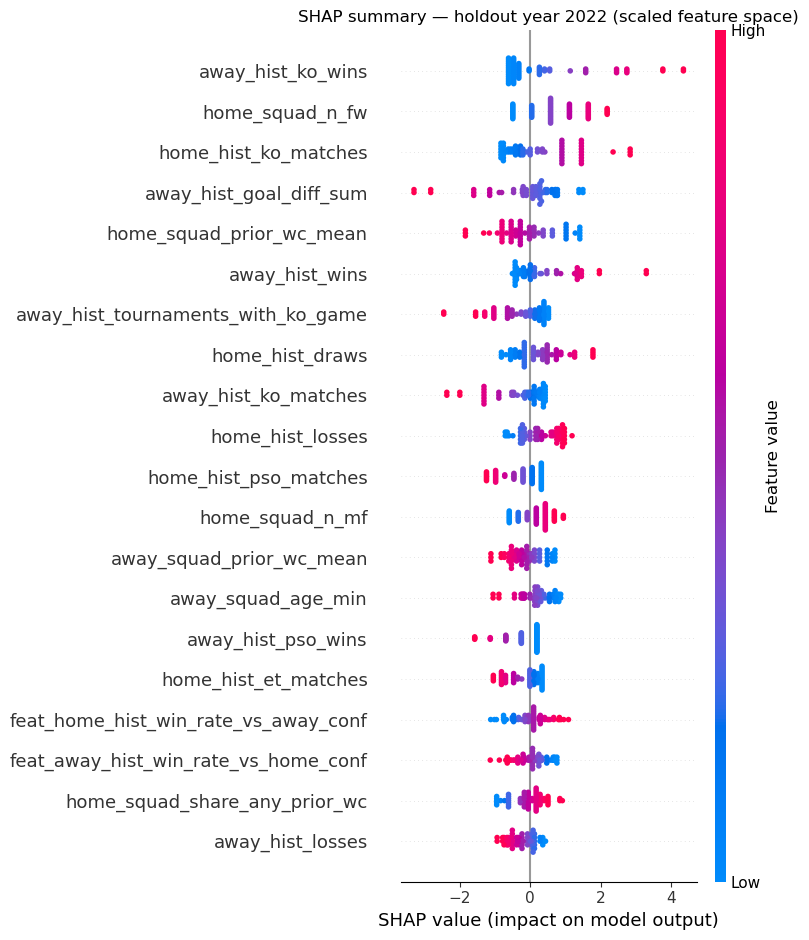

In [5]:
top_k = 20
top_feat = imp_df.head(top_k)["feature"].tolist()
idx = [num_cols.index(f) for f in top_feat]
vals = mean_abs_shap[idx]
order = np.argsort(vals)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(np.array(top_feat)[order], vals[order], color="steelblue")
ax.set_xlabel("Mean |SHAP| (averaged over LOTO test folds)")
ax.set_title(f"Top {top_k} features — men's World Cup LOTO")
plt.tight_layout()
plt.show()

assert shap_explanation_2022 is not None
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_explanation_2022.values,
    X_test_scaled_2022,
    feature_names=num_cols,
    max_display=top_k,
    show=False,
)
plt.title("SHAP summary — holdout year 2022 (scaled feature space)")
plt.tight_layout()
plt.show()

## 5) Takeaways (auto-filled from this run)

Numbers update when you re-run the notebook.

In [6]:
auc_m, auc_s = loto_df["roc_auc"].mean(), loto_df["roc_auc"].std()
acc_m = loto_df["accuracy"].mean()
top3 = imp_df.head(3)["feature"].tolist()
print("--- Copy-friendly bullets ---")
print(
    f"• Men's-only sample: {len(dm)} matches across {len(MENS_WORLD_CUP_YEARS)} World Cups."
)
print(
    f"• LOTO (leave-one-tournament-out) ROC-AUC: mean {auc_m:.3f}, sd {auc_s:.3f} "
    f"(range {loto_df['roc_auc'].min():.3f}–{loto_df['roc_auc'].max():.3f})."
)
print(f"• Mean accuracy across LOTO folds: {acc_m:.3f}.")
print(
    "• Features with highest mean |SHAP| (LOTO-averaged): "
    + ", ".join(top3)
    + " (see bar chart and 2022 summary plot for direction)."
)
print(
    "• SHAP summary plot uses the 2022 holdout; bar chart pools signal across all holdouts."
)

--- Copy-friendly bullets ---
• Men's-only sample: 384 matches across 6 World Cups.
• LOTO (leave-one-tournament-out) ROC-AUC: mean 0.661, sd 0.067 (range 0.568–0.766).
• Mean accuracy across LOTO folds: 0.620.
• Features with highest mean |SHAP| (LOTO-averaged): home_hist_et_matches, home_squad_n_fw, away_hist_wins (see bar chart and 2022 summary plot for direction).
• SHAP summary plot uses the 2022 holdout; bar chart pools signal across all holdouts.


## 6) Interpretation summary — do top SHAP features make sense?

### Overall verdict

The ranking is **largely sensible** for predicting **home win vs. not** using **prematch / pre-tournament** inputs. The model leans on **historical tournament strength**, **knockout and penalty-shootout experience**, **squad World Cup experience and structure**, and **opponent-specific history** (including vs. the home team’s confederation). That matches both the feature design and basic football intuition.

### Top 15 features (reference table — values from a full pipeline run)

| Rank | Feature | Mean abs SHAP (LOTO avg.) | Interpretation |
|------|---------|---------------------------|----------------|
| 1 | `home_hist_et_matches` | 0.532 | **Caution:** counts past WC matches that went to extra time; may proxy “deep knockout involvement” but overlaps KO/PSO history. Rank can shift under correlation (see notes below). |
| 2 | `home_squad_n_fw` | 0.503 | Squad structure (forwards); indirect link to style/selection, plausible as a coarse signal. |
| 3 | `away_hist_wins` | 0.495 | **Strong:** better historical away side → lower home-win probability; clear narrative. |
| 4 | `home_hist_draws` | 0.475 | Indirect (draw-heavy history ↔ style or level); weaker story than wins/KO metrics. |
| 5 | `home_hist_ko_matches` | 0.458 | **Strong:** home team’s knockout exposure → strength / consistency proxy. |
| 6 | `home_squad_share_any_prior_wc` | 0.446 | **Strong:** share of squad with prior WC experience; standard “tournament experience” angle. |
| 7 | `home_squad_prior_wc_mean` | 0.436 | **Strong:** average prior WC counts in squad; same family as row 6. |
| 8 | `away_hist_ko_matches` | 0.422 | **Strong:** away team knockout pedigree → tougher opponent. |
| 9 | `away_hist_pso_wins` | 0.384 | Plausible “big-game” proxy; small-sample noise possible. |
| 10 | `feat_away_hist_win_rate_vs_home_conf` | 0.349 | **Strong:** away vs. home confederation historically — good matchup-style feature. |
| 11 | `home_hist_pso_wins` | 0.346 | Overlaps with knockout / tight-game history; interpret with KO/PSO family. |
| 12 | `away_squad_age_min` | 0.342 | Youngest squad member age; youth vs. experience; relationship to outcome need not be monotone. |
| 13 | `home_hist_frac_tournaments_reached_ko` | 0.338 | **Strong:** fraction of past tournaments where home reached KO — stability / quality. |
| 14 | `home_hist_pso_matches` | 0.330 | Same family as PSO wins; often collinear with other `hist_*` features. |
| 15 | `away_hist_ko_wins` | 0.317 | Away knockout wins — opponent quality; consistent with rows 3 and 8. |

### Takeaways

- **Opponent side:** `away_hist_wins`, `away_hist_ko_*`, `away_hist_pso_wins`, and `feat_away_hist_win_rate_vs_home_conf` support a clean story: **stronger away teams reduce home win odds**.
- **Home side:** `home_hist_ko_matches`, `home_hist_frac_tournaments_reached_ko`, and squad WC-experience features support **quality + tournament experience**.
- **Read rank 1 carefully:** `home_hist_et_matches` is less intuitive alone than “wins” or “KO progression”; with **~96 correlated numeric features** and a **linear** model, **SHAP splits mass across correlated variables** — treat **families** (hist strength, KO/PSO/ET, squad) as important rather than over-interpreting a single ordering.
- **Methods:** SHAP here explains **this fitted logistic model in scaled space**, not causal effects. Use the **2022 beeswarm** for **direction** (how scaled feature values move log-odds) alongside the **LOTO-averaged mean absolute SHAP** bar view. `class_weight="balanced"` adjusts for label frequency but does not remove **year-to-year** difficulty (visible in LOTO AUC spread).

